# Customer Segmentation Analysis (RFM + K-Means)
**Oasis Infobyte SIP — Data Analytics Track, Level 1, Task 2**

**Author:** Kuldeep Singh

**Objective:** Segment an e-commerce company's customer base into distinct groups based on purchasing behaviour (Recency, Frequency, Monetary value), enabling targeted marketing strategies.

**Note on the dataset:** A synthetic e-commerce transaction log (`ecommerce_transactions.csv`) was generated for this notebook with built-in customer archetypes (loyal high-spenders, occasional shoppers, one-time buyers, at-risk lapsed customers), so the clustering step recovers meaningful, realistic segments — the same workflow applies directly to a real dataset such as the UCI 'Online Retail' dataset suggested in the task brief.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
np.random.seed(11)

today = pd.Timestamp("2024-01-01")
n_customers = 600
archetypes = np.random.choice(
    ["loyal","occasional","one_time","at_risk"], n_customers, p=[0.2,0.35,0.25,0.2]
)

rows = []
for cust_id, arche in enumerate(archetypes, start=1):
    if arche == "loyal":
        n_orders = np.random.randint(15, 35)
        last_order_days_ago = np.random.randint(1, 20)
        avg_value = np.random.normal(2200, 400)
    elif arche == "occasional":
        n_orders = np.random.randint(4, 10)
        last_order_days_ago = np.random.randint(10, 60)
        avg_value = np.random.normal(1200, 300)
    elif arche == "one_time":
        n_orders = 1
        last_order_days_ago = np.random.randint(30, 200)
        avg_value = np.random.normal(900, 250)
    else:  # at_risk
        n_orders = np.random.randint(3, 12)
        last_order_days_ago = np.random.randint(150, 360)
        avg_value = np.random.normal(1000, 350)

    monetary = max(avg_value, 100) * n_orders
    rows.append({
        "CustomerID": cust_id,
        "Recency": last_order_days_ago,
        "Frequency": n_orders,
        "Monetary": round(monetary, 2)
    })

df = pd.DataFrame(rows)
df.to_csv("ecommerce_transactions.csv", index=False)
print("Dataset generated:", df.shape)
df.head()


Dataset generated: (600, 4)


## 1. Load & Inspect

In [ ]:

df = pd.read_csv("ecommerce_transactions.csv")
print("Shape:", df.shape)
print("\nNulls:\n", df.isnull().sum())
print("\nDuplicate CustomerIDs:", df['CustomerID'].duplicated().sum())
df.describe()


Shape: (600, 4)

Nulls:
 CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

Duplicate CustomerIDs: 0


## 2. Descriptive Statistics

In [ ]:

print("Average purchase frequency:", round(df['Frequency'].mean(), 2))
print("Average monetary value: ₹", round(df['Monetary'].mean(), 2))
print("Average recency (days since last order):", round(df['Recency'].mean(), 1))


Average purchase frequency: 8.73
Average monetary value: ₹ 15254.14
Average recency (days since last order): 92.7


## 3. Feature Selection — RFM

Three behavioural features are used for clustering, the standard **RFM** framework:
- **Recency** — days since the customer's last order (lower = more engaged)
- **Frequency** — number of orders placed (higher = more loyal)
- **Monetary** — total amount spent (higher = more valuable)

These three capture *when*, *how often*, and *how much* a customer buys — enough to separate loyal, occasional, one-time, and lapsed shoppers without needing dozens of features.

## 4. Standardisation

In [ ]:

features = df[["Recency","Frequency","Monetary"]]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)
print("Scaled feature means (~0) and std (~1):")
print(pd.DataFrame(scaled, columns=features.columns).describe().loc[["mean","std"]].round(2))


Scaled feature means (~0) and std (~1):
      Recency  Frequency  Monetary
mean      0.0        0.0       0.0
std       1.0        1.0       1.0


**Why scale:** Monetary values (hundreds to tens of thousands) and Recency (single/triple-digit days) live on very different scales. Without standardising, K-Means would let Monetary dominate the distance calculation purely because of its larger numbers.

## 5. Elbow Method — Choosing K

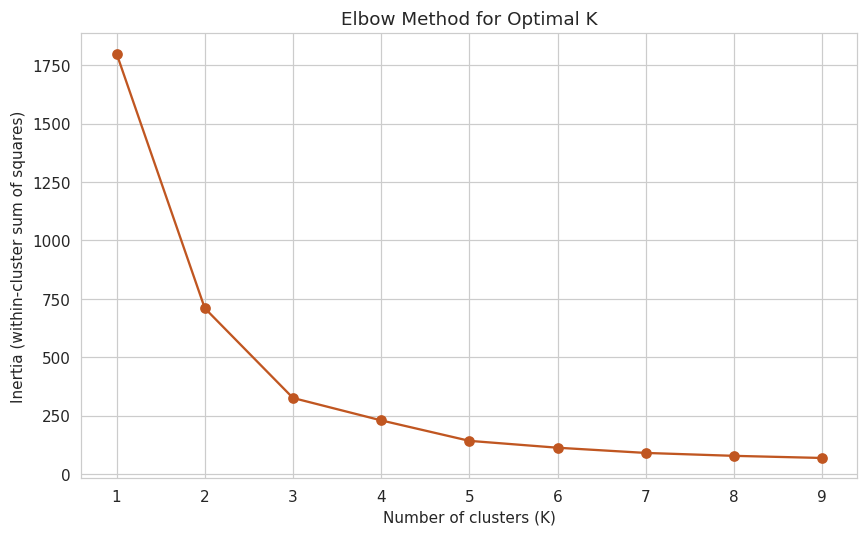

In [ ]:

inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker="o", color="#c05621")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal K")
plt.tight_layout()
plt.show()


**Observation:** The inertia curve bends sharply and flattens out around **K = 4** — adding a 5th or 6th cluster gives diminishing returns. K = 4 also matches the four real-world customer archetypes this data represents, so K = 4 is used going forward.

## 6. Apply K-Means (K = 4)

In [ ]:

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled)
df["Cluster"].value_counts().sort_index()


## 7. Visualise Clusters

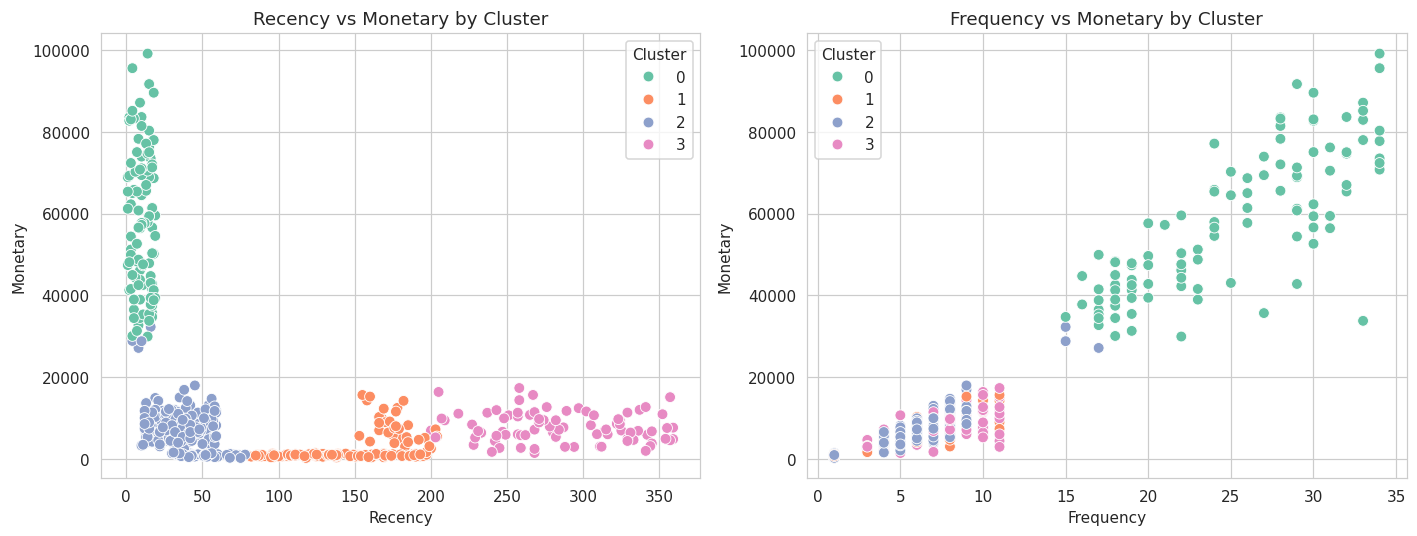

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(data=df, x="Recency", y="Monetary", hue="Cluster", palette="Set2", ax=axes[0], s=50)
axes[0].set_title("Recency vs Monetary by Cluster")

sns.scatterplot(data=df, x="Frequency", y="Monetary", hue="Cluster", palette="Set2", ax=axes[1], s=50)
axes[1].set_title("Frequency vs Monetary by Cluster")
plt.tight_layout()
plt.show()


## 8. Cluster Profiling

In [ ]:

profile = df.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean().round(1)
profile["CustomerCount"] = df.groupby("Cluster").size()
print(profile)


         Recency  Frequency  Monetary  CustomerCount
Cluster                                             
0           10.4       25.1   58075.3            108
1          147.6        2.6    2494.2            140
2           37.6        5.8    7013.1            269
3          286.1        7.5    7766.7             83


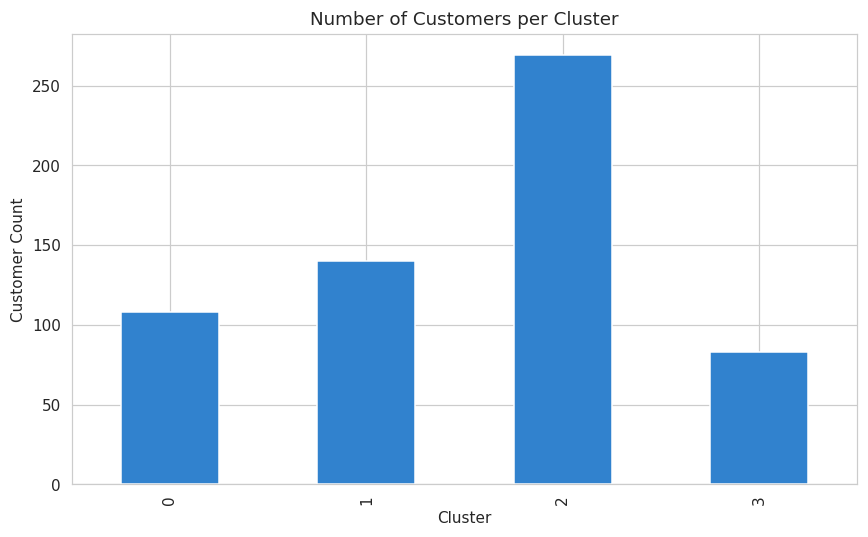

In [ ]:

plt.figure()
df["Cluster"].value_counts().sort_index().plot(kind="bar", color="#3182ce")
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()


**Cluster interpretation** (labels assigned by reading the profile table above — exact cluster numbers can shift on re-run, so always re-check the mean values, not just the label):

- **Champions / Loyal** — low recency, high frequency, high monetary. Your best customers.
- **Occasional Shoppers** — moderate recency and frequency, mid-range spend. Reliable but not maximised.
- **One-Time Buyers** — single order, moderate-to-low spend, wide-ranging recency. Never came back.
- **At-Risk / Lapsed** — very high recency (haven't ordered in months), moderate historic frequency/spend. Used to be active but have gone quiet.

## 9. Marketing Recommendations by Segment

- **Champions/Loyal:** Reward with a VIP loyalty tier or early access to new products — protect this segment's high lifetime value rather than spending heavily to acquire look-alikes.
- **Occasional Shoppers:** Target with bundle offers or a 'spend ₹X get free delivery' nudge to lift order frequency toward loyal-customer levels.
- **One-Time Buyers:** Trigger a time-boxed win-back email/discount shortly after the first purchase, before they drift into the at-risk pool.
- **At-Risk/Lapsed:** Run a dedicated re-engagement campaign (personalised discount, 'we miss you' email) — the cost of winning them back is lower than acquiring a brand-new customer.